In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import protfasta
import metapredict

# 1. Properties of my sequences

In [2]:
seq_dict = protfasta.read_fasta("../output/interpro_uniprot_evid_1_2.fasta")
seq_df = pd.DataFrame({"id" : seq_dict.keys(), "seq" : seq_dict.values()})
seq_df

,id,seq
0,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
1,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
2,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...
3,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...
4,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
...,...,...
137431,tr|W8C846|W8C846_CERCA (Mediterranean fruit fl...,MNNITRLLANCTLNTTRCHLKYNAAALTAAIQLRGKCKVVVKPAPG...
137432,tr|W8CA25|W8CA25_CERCA (Mediterranean fruit fl...,MAGRPRRQAATRTAQIIEISDSEDDNSVSKNKRRRRDSSFSPPPTK...
137433,tr|W8QUS6|W8QUS6_MIMNO Cold shock domain prote...,MSDSEKQPEEKEEPKKNVIATKVTGTVKWFNVKSGYGFINRDDTKE...
137434,tr|X5CQH7|X5CQH7_9EUKA 30S plastidal ribosomal...,MSSARPLVLIASLLGASEALQSCHTRLVSSRVAATPRAAWALTMCD...


In [3]:
seq_df["net charge"] = seq_df["seq"].str.count('R') + seq_df["seq"].str.count('K') - seq_df["seq"].str.count('D') - seq_df["seq"].str.count('E')
seq_df["hydrophobics_prop"] = (seq_df["seq"].str.count('W') + seq_df["seq"].str.count('F') + seq_df["seq"].str.count('Y') + seq_df["seq"].str.count('L')) / seq_df["seq"].str.len()
seq_df

,id,seq,net charge,hydrophobics_prop
0,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,-9,0.106472
1,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,-14,0.109804
2,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...,6,0.128668
3,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...,10,0.162011
4,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,-26,0.118033
...,...,...,...,...
137431,tr|W8C846|W8C846_CERCA (Mediterranean fruit fl...,MNNITRLLANCTLNTTRCHLKYNAAALTAAIQLRGKCKVVVKPAPG...,26,0.150000
137432,tr|W8CA25|W8CA25_CERCA (Mediterranean fruit fl...,MAGRPRRQAATRTAQIIEISDSEDDNSVSKNKRRRRDSSFSPPPTK...,14,0.144835
137433,tr|W8QUS6|W8QUS6_MIMNO Cold shock domain prote...,MSDSEKQPEEKEEPKKNVIATKVTGTVKWFNVKSGYGFINRDDTKE...,13,0.112245
137434,tr|X5CQH7|X5CQH7_9EUKA 30S plastidal ribosomal...,MSSARPLVLIASLLGASEALQSCHTRLVSSRVAATPRAAWALTMCD...,-9,0.127660


In [4]:
from joblib import Parallel, delayed
from tqdm import tqdm

# Define the function once (so joblib can pickle it)
def calc_percent_disorder(seq):
    return metapredict.percent_disorder(seq)

# Use joblib for parallelization and tqdm for progress
seq_df["percent_disorder"] = Parallel(
    n_jobs=-1  # Use all cores
)(
    delayed(calc_percent_disorder)(seq) 
    for seq in tqdm(seq_df["seq"], desc="Calculating disorder")
)


Calculating disorder:  41%|████      | 55768/137436 [04:37<08:28, 160.75it/s]

KeyboardInterrupt: 

In [ ]:
seq_df.to_csv("../data/SK_interpro_uniprot_evid_1_2_props.csv")

# 2. Properties of Claire's seqs

In [ ]:
def return_df(fasta_path):
    fasta_dict = protfasta.read_fasta(fasta_path, invalid_sequence_action='ignore')
    return pd.DataFrame({'id' : fasta_dict.keys(), 'seq' : fasta_dict.values()})
    
cl_seqs = return_df("../output/cl_seqs.fasta")
cl_seqs

In [ ]:
cl_seqs["net charge"] = cl_seqs["seq"].str.count('R') + cl_seqs["seq"].str.count('K') - cl_seqs["seq"].str.count('D') - cl_seqs["seq"].str.count('E')
cl_seqs["hydrophobics_prop"] = (cl_seqs["seq"].str.count('W') + cl_seqs["seq"].str.count('F') + cl_seqs["seq"].str.count('Y') + cl_seqs["seq"].str.count('L')) / cl_seqs["seq"].str.len()
cl_seqs

In [ ]:
# Use joblib for parallelization and tqdm for progress
cl_seqs["percent_disorder"] = Parallel(
    n_jobs=-1  # Use all cores
)(
    delayed(calc_percent_disorder)(seq) 
    for seq in tqdm(cl_seqs["seq"], desc="Calculating disorder")
)

# 3. Lambert TFs comparison

In [ ]:
lambert_TFs = protfasta.read_fasta("../data/lambert_TFs_10-21-24_with_DBD_coords.fasta")
lambert_TFs = pd.DataFrame({"id" : lambert_TFs.keys(), "seq" : lambert_TFs.values() })
lambert_TFs

In [ ]:
lambert_TFs["net charge"] = lambert_TFs["seq"].str.count('R') + lambert_TFs["seq"].str.count('K') - lambert_TFs["seq"].str.count('D') - lambert_TFs["seq"].str.count('E')
lambert_TFs["hydrophobics_prop"] = (lambert_TFs["seq"].str.count('W') + lambert_TFs["seq"].str.count('F') + lambert_TFs["seq"].str.count('Y') + lambert_TFs["seq"].str.count('L')) / lambert_TFs["seq"].str.len()
lambert_TFs

In [ ]:
# Use joblib for parallelization and tqdm for progress
lambert_TFs["percent_disorder"] = Parallel(
    n_jobs=-1  # Use all cores
)(
    delayed(calc_percent_disorder)(seq) 
    for seq in tqdm(lambert_TFs["seq"], desc="Calculating disorder")
)


# 4. Plotting

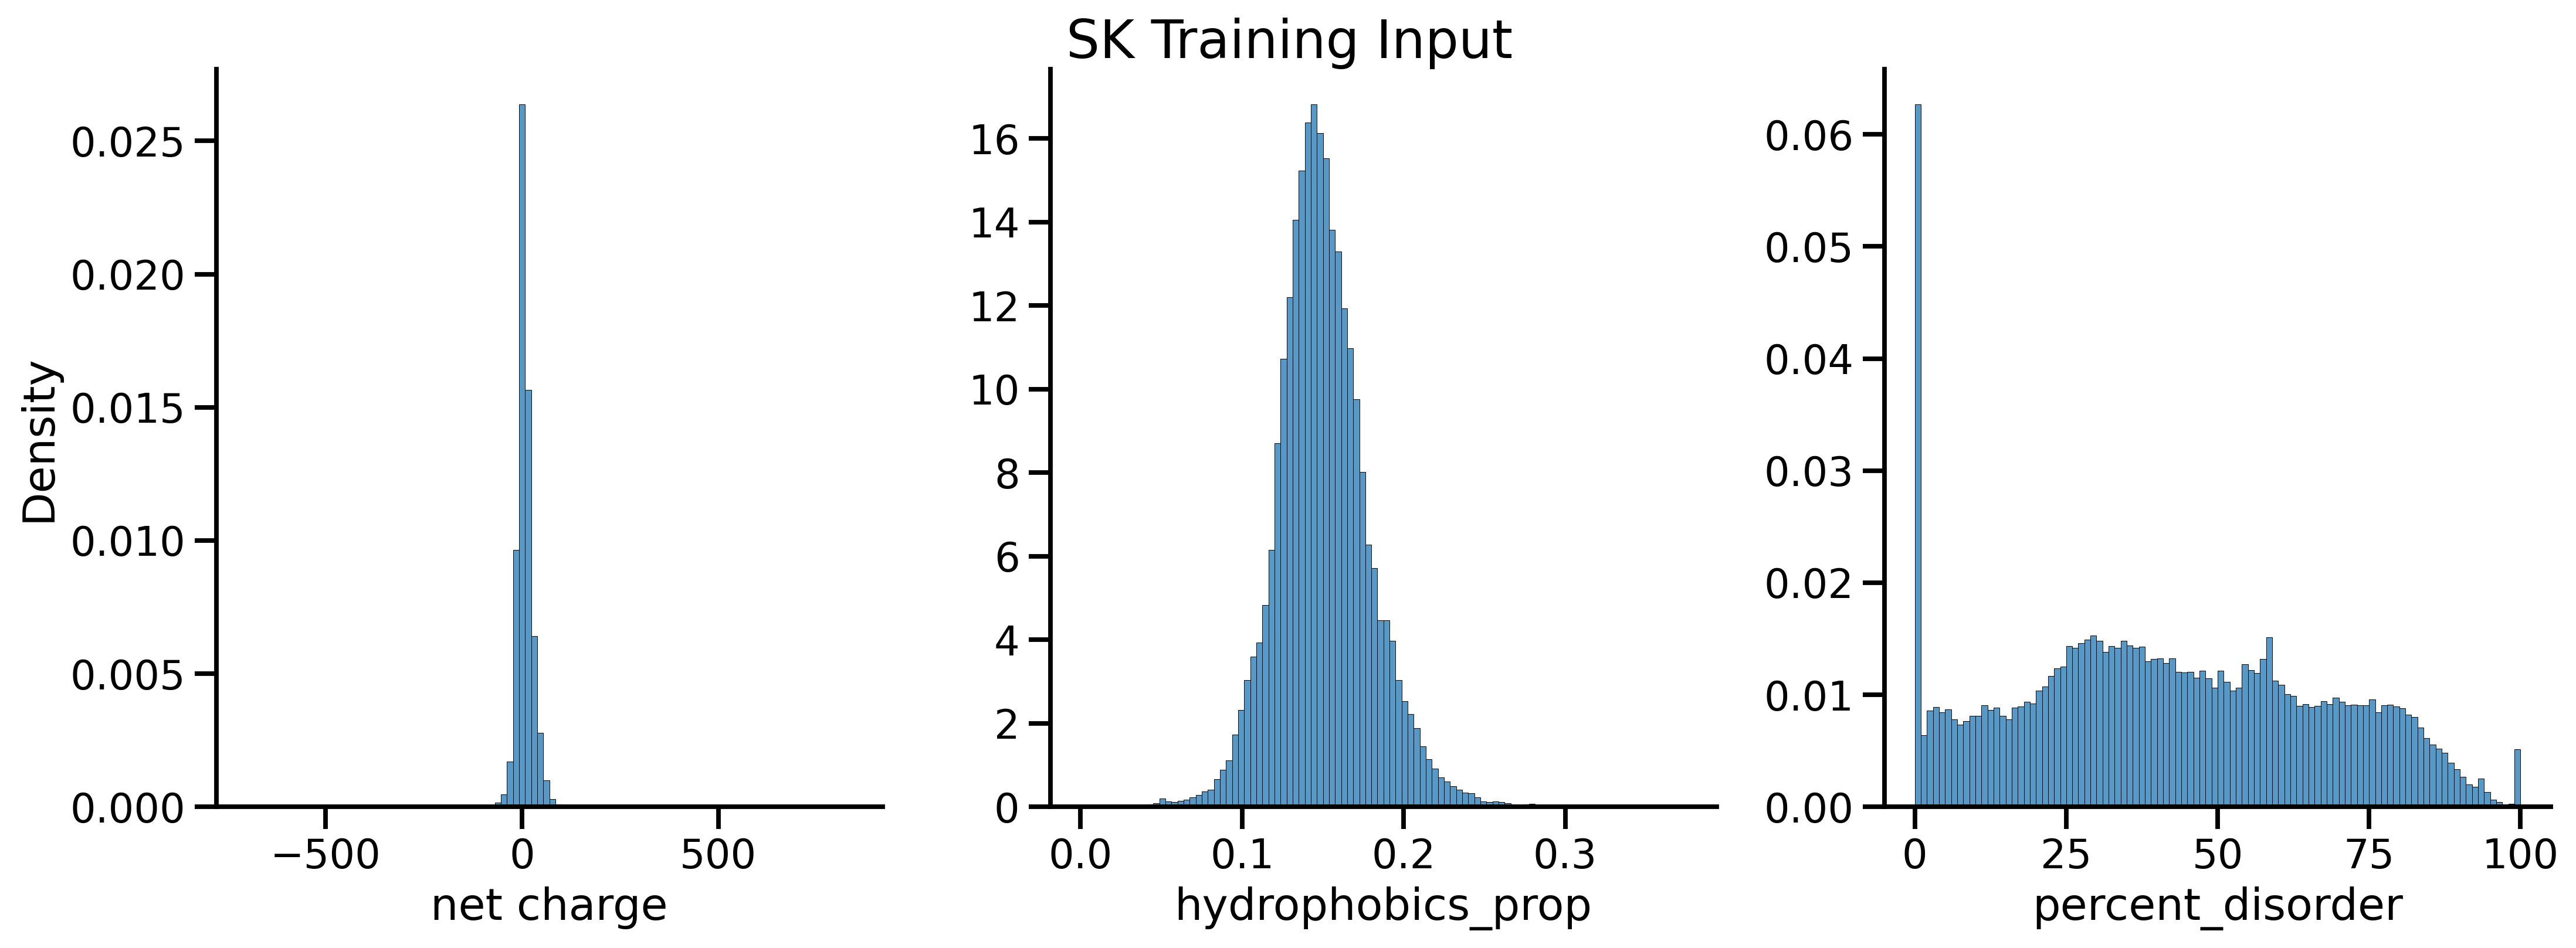

In [7]:
sns.set_context('talk')

fig, axs = plt.subplots(1, 3, figsize = (15, 6), dpi = 300)

sns.histplot(seq_df["net charge"], ax = axs[0], stat = 'density', bins = 100)
sns.histplot(seq_df["hydrophobics_prop"], ax = axs[1], stat = 'density', bins = 100)
sns.histplot(seq_df["percent_disorder"], ax = axs[2], stat = 'density', bins = 100)

axs[1].set_ylabel("")
axs[2].set_ylabel("")
sns.despine()
fig.suptitle("SK Training Input", y = 0.91)
plt.tight_layout()
plt.show()



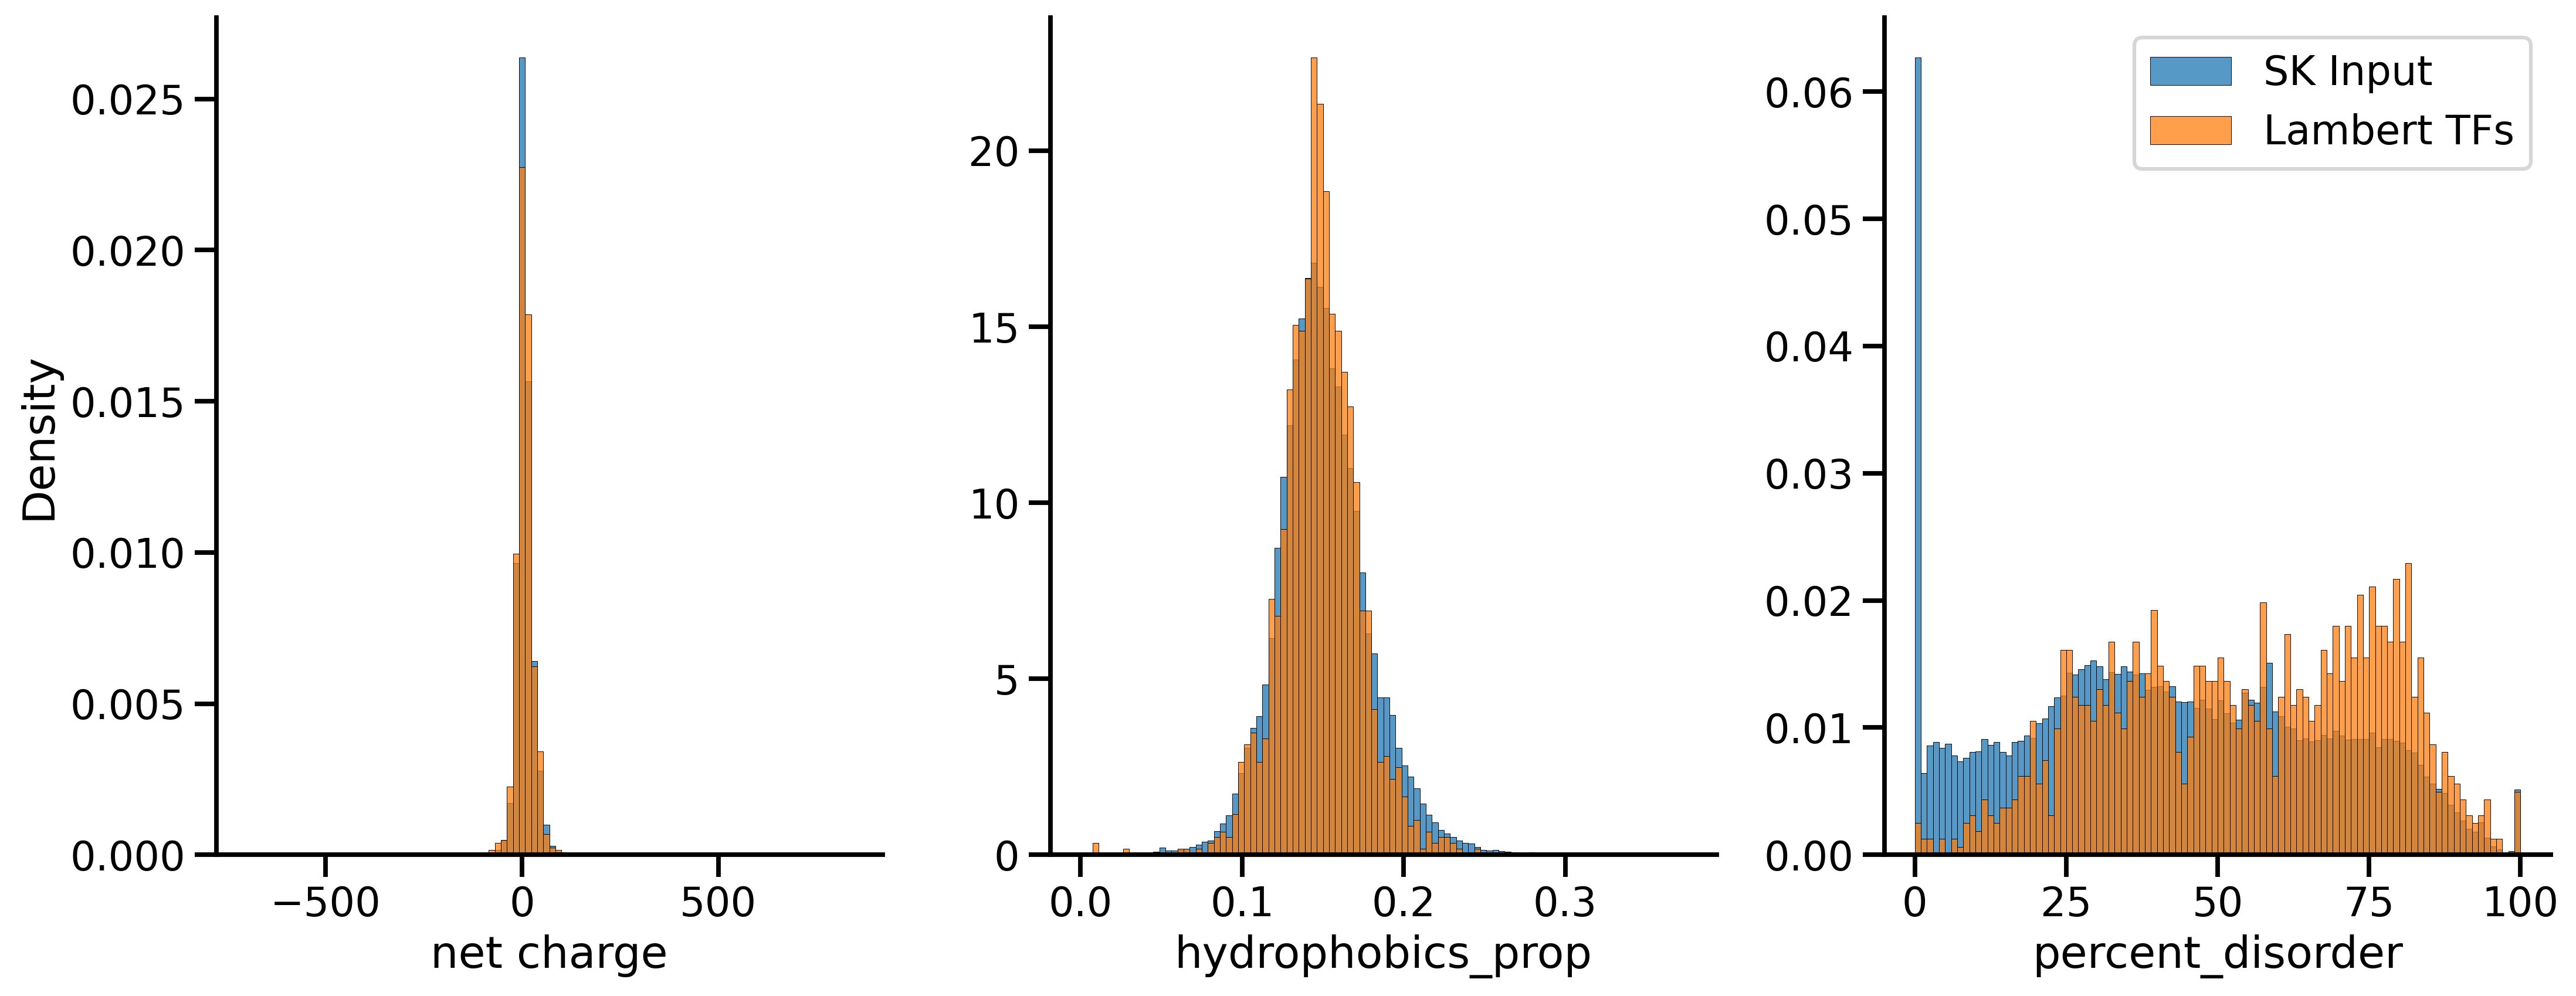

In [21]:
import numpy as np

sns.set_context('talk')

fig, axs = plt.subplots(1, 3, figsize=(15, 6), dpi=300)

# Calculate bin edges for each property
net_charge_bins = np.histogram_bin_edges(
    np.concatenate([seq_df["net charge"], lambert_TFs["net charge"]]), bins=100
)
hydrophobics_prop_bins = np.histogram_bin_edges(
    np.concatenate([seq_df["hydrophobics_prop"], lambert_TFs["hydrophobics_prop"]]), bins=100
)
percent_disorder_bins = np.histogram_bin_edges(
    np.concatenate([seq_df["percent_disorder"], lambert_TFs["percent_disorder"]]), bins=100
)

# Plot histograms with shared bins
sns.histplot(seq_df["net charge"], ax=axs[0], label="SK Input", stat='density', bins=net_charge_bins)
sns.histplot(lambert_TFs["net charge"], ax=axs[0], label="Lambert TFs", stat='density', bins=net_charge_bins)

sns.histplot(seq_df["hydrophobics_prop"], ax=axs[1], label="SK Input", stat='density', bins=hydrophobics_prop_bins)
sns.histplot(lambert_TFs["hydrophobics_prop"], ax=axs[1], label="Lambert TFs", stat='density', bins=hydrophobics_prop_bins)

sns.histplot(seq_df["percent_disorder"], ax=axs[2], label="SK Input", stat='density', bins=percent_disorder_bins)
sns.histplot(lambert_TFs["percent_disorder"], ax=axs[2], label="Lambert TFs", stat='density', bins=percent_disorder_bins)

axs[1].set_ylabel("")
axs[2].set_ylabel("")
sns.despine()
plt.tight_layout()
plt.legend()
plt.show()


In [ ]:
len(set(lambert_TFs["seq"]) & set(seq_df["seq"]))
# Almost all lambert TFs are in my training set

1452